# GB84 Model Testing Using in-situ measurements from Cabauw, NL

A notebook to perform test runs with the python implementation of the Georgakakos and Bras model from *"A Hydrologically Useful Station Precipitation Model"* (1984)

This Jupyter Notebook tests a precipitation model using validated data from the CESAR network as inputs, with a 10min resolution.

The input data used in this model consist of a combined dataset derived from the **Cesar Network surface data** and **Cloudnet MWR profiles** corresponding to Cabauw.
#### Required Inputs

- **Surface Inputs** (from ERA5 Single Levels):
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature



In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from GB84 import calculations_for_convection, rho_m, v,cloud_heights, h_out, phi, f, non_dim_numbers
from scipy import signal
from scipy.stats import pearsonr

# Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)
4. [Result Analysis](#Result-Analysis)


## Loading the Data


After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.


In [2]:
#choose time period of runs
slice_str = "2024-07-01 00:00:00, 2024-07-04 00:00:00"
slice_tuple = tuple(slice_str.split(", "))

#### CESAR surface measurements 

In [3]:
ground_measurements = xr.open_mfdataset(r'..\data\Cabauw_cesar_surface\cesar_surface_meteo_lc1_t10_v1.0_202407.nc')
var = ['TA002','P0','TD002','RH002']
measurements = ground_measurements[var]
measurements = measurements.dropna(dim='time',how='any')

measurements_used = measurements.sel(time=slice(*slice_tuple))

In [4]:
time = measurements_used.sel(time=slice(*slice_tuple)).time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Radiometer LWP 

The liquid water path as measured from the MWR in Cabauw, to be used as the initial state

In [5]:
radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')
radiometer_lwp = radiometer['lwp'].sel(time=time,method='nearest')

C:\Users\chari\AppData\Local\Temp\ipykernel_24060\3086603202.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  radiometer = xr.open_mfdataset(r'..\data\Cabaw_radiometer\*.nc')


Storing the time values and the timestep.

In [6]:
#inputs

#temperature on the ground
T_surf = measurements_used['TA002'].values


#pressure
p_surf = measurements_used['P0'].values*100#,measurements_used['P0'].values*100+100))   #[Pa]

#dew point temperature
T_d_arr = np.array((measurements_used['TD002'].values,measurements_used['TD002'].values+1,measurements_used['TD002'].values-1)) #[K]

#state
X = np.zeros((3,len(p_surf)))
#X1 = np.zeros(len(T_surf))
X[:,0] = radiometer_lwp[0]   #initial state in kg/m2 taken from radiometer LWP
#X1[0] = radiometer_lwp[0]   #initial state in kg/m2 taken from radiometer LWP

In [7]:
T_surf[0]

np.float32(287.07)

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [8]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=time,method='nearest')
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\ES25\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


### Testing the model

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions `(time)`.


In [9]:
P = np.zeros((3,len(p_surf)))
Z_b_arr = np.zeros((3,len(p_surf)))
Z_c_arr = np.zeros((3,len(p_surf)))
T_m_arr = np.zeros((3,len(p_surf)))
P_0 = np.zeros(len(p_surf))
f_arr = np.zeros(len(p_surf))
h_arr = np.zeros(len(p_surf))
f_arr = np.zeros((3,len(p_surf)))
v_arr = np.zeros((3,len(p_surf)))
D_c_arr = np.zeros((3,len(p_surf)))
O_b_arr = np.zeros((3,len(p_surf)))
ql_total = np.zeros((3,len(p_surf)))
phi_arr = np.zeros((3,len(p_surf)))
N_v_arr = np.zeros((3,len(p_surf))) 
p_t_arr = np.zeros((3,len(p_surf))) 

In [10]:
from GB84 import w

#### Model running loop

Loop for the thermodynamical calculations at each timestep and then for the calculation of precipitation rates and state propagation in time

In [11]:
#loop for finding the precipitation given the T_0 and p

for a in range(3):
    for i in range(0,len(p_surf)):
    #inputs
        T_0 = T_surf[i]
        p_0 = p_surf[i]
        T_d = T_d_arr[a,i]

        #thermodynamics and in cloud calculations
        p_s,T_s,p_t, T_m, T_t,T_s_up, p_s_up = calculations_for_convection(T_0, T_d, p_0, obs=False).run()
        T_m_arr[a,i] = T_m
        Z_c,Z_b = cloud_heights(T_s,T_t,T_0,p_s,p_t,p_0)
        Z_b_arr[a,i] = Z_b
        Z_c_arr[a,i] = Z_c 
        p_t_arr[a,i] = p_t
         
        ql_total[a,i] = w(T_d,p_0) - w(T_t,p_t)
        #fluxes
        rho = rho_m(T_s,T_t,p_s,p_t)
        v_updr = v(T_m,T_s_up)
        v_arr[a,i] = v_updr
        from GB84 import non_dim_numbers
        N_v_arr[a,i] = non_dim_numbers(v_updr)[1]
        O_b,O_t,h_v = h_out(v_updr,Z_c).run()   #outflows and sources of water
        O_b_arr[a,i] = O_b
        #precipitation
        P[a,i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()[0]*X[a,i]
        D_c_arr[a,i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()[1]
        phi_arr[a,i] = phi(T_0, p_0, T_d, Z_b, Z_c,v_updr).calculate_phi()[1]
        #f_arr[a,i] = f(T_d,p_0,p_t,T_t,rho,v_updr)
        #state update
        if i<(len(p_surf)-1):
            X[a,i+1] = X[a,i] + dt_seconds[i]*(f(T_d,p_0,p_t,T_t,rho,v_updr) - h_out(v_updr,Z_c).run()[2]*X[a,i])


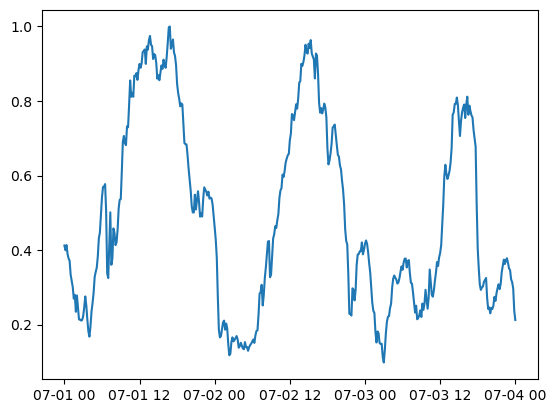

In [14]:
outflow = X[0]*4/Z_c_arr[0]*O_b_arr[0]

#plt.plot(time,outflow/max(outflow))
plt.plot(time,D_c_arr[0]/D_c_arr[0].max())
#plt.plot(time,P[0]/P[0].max())
plt.show()

In [15]:
print(np.mean(Z_c_arr[0]),np.mean(Z_c_arr[1]),np.mean(Z_c_arr[2]))

5530.890269746618 5679.426247497662 5383.9668658572455


In [16]:
print(np.mean(T_m_arr[0]),np.mean(T_m_arr[1]),np.mean(T_m_arr[2]))

276.9059500039346 278.07774329879476 275.74492036674724


In [17]:
print(np.mean(v_arr[0]),np.mean(v_arr[1]),np.mean(v_arr[2]))

0.10906150965846548 0.11083065904237481 0.10725822620559608


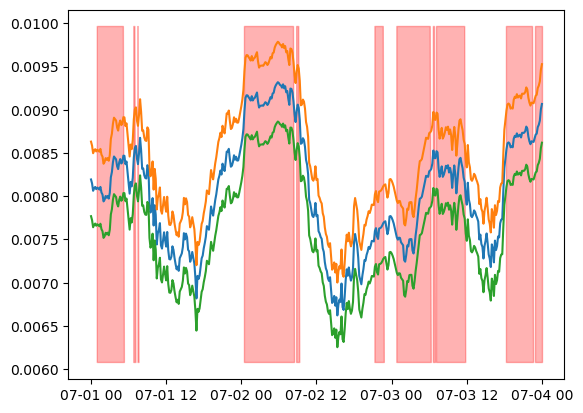

In [18]:
plt.plot(time,ql_total[0])
plt.plot(time,ql_total[1])
plt.plot(time,ql_total[2])
y_min, y_max = plt.ylim()

# Add red shaded areas - this approach avoids indexing issues
mask = (P[0]*3600 > 0.2).values if hasattr(P[0]*3600, 'values') else (P[0]*3600 > 0.2)  # Handle xarray
#plt.axhline(y=np.mean(T_surf[mask] -T_d_arr[mask]), xmin=0, xmax=1, color='r', label='T_d')
mask_actual = (rain_rate > 0.2).values if hasattr(rain_rate, 'values') else (rain_rate > 0.2)
plt.fill_between(time, y_min, y_max, where=mask, 
                 alpha=0.3, color='red', label='P > 0', interpolate=True)
plt.show()

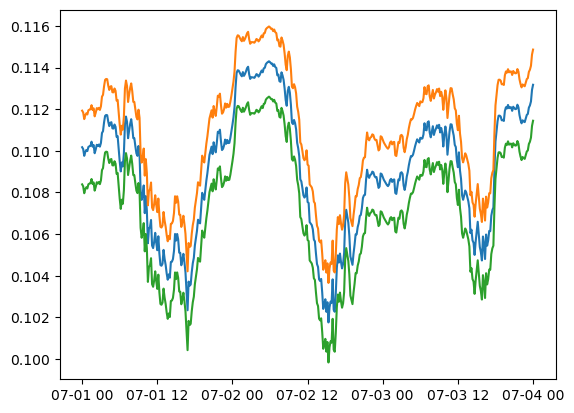

In [19]:
plt.plot(time,v_arr[0])
plt.plot(time,v_arr[1])
plt.plot(time,v_arr[2])
plt.show()

In [21]:
n_d

array([1.39685300e+02, 1.27535142e+02, 1.16441832e+02, 1.06313446e+02,
       9.70660500e+01, 8.86230147e+01, 8.09143746e+01, 7.38762504e+01,
       6.74503189e+01, 6.15833301e+01, 5.62266660e+01, 5.13359372e+01,
       4.68706156e+01, 4.27936983e+01, 3.90714009e+01, 3.56728778e+01,
       3.25699662e+01, 2.97369533e+01, 2.71503626e+01, 2.47887596e+01,
       2.26325745e+01, 2.06639395e+01, 1.88665410e+01, 1.72254845e+01,
       1.57271710e+01, 1.43591844e+01, 1.31101885e+01, 1.19698332e+01,
       1.09286687e+01, 9.97806715e+00, 9.11015120e+00, 8.31772864e+00,
       7.59423287e+00, 6.93366848e+00, 6.33056155e+00, 5.77991429e+00,
       5.27716363e+00, 4.81814342e+00, 4.39904988e+00, 4.01641008e+00,
       3.66705321e+00, 3.34808422e+00, 3.05685991e+00, 2.79096698e+00,
       2.54820206e+00, 2.32655340e+00, 2.12418426e+00, 1.93941768e+00,
       1.77072253e+00, 1.61670088e+00, 1.47607640e+00, 1.34768378e+00,
       1.23045904e+00, 1.12343080e+00, 1.02571212e+00, 9.36493248e-01,
      

In [22]:
n_d

array([1.39685300e+02, 1.27535142e+02, 1.16441832e+02, 1.06313446e+02,
       9.70660500e+01, 8.86230147e+01, 8.09143746e+01, 7.38762504e+01,
       6.74503189e+01, 6.15833301e+01, 5.62266660e+01, 5.13359372e+01,
       4.68706156e+01, 4.27936983e+01, 3.90714009e+01, 3.56728778e+01,
       3.25699662e+01, 2.97369533e+01, 2.71503626e+01, 2.47887596e+01,
       2.26325745e+01, 2.06639395e+01, 1.88665410e+01, 1.72254845e+01,
       1.57271710e+01, 1.43591844e+01, 1.31101885e+01, 1.19698332e+01,
       1.09286687e+01, 9.97806715e+00, 9.11015120e+00, 8.31772864e+00,
       7.59423287e+00, 6.93366848e+00, 6.33056155e+00, 5.77991429e+00,
       5.27716363e+00, 4.81814342e+00, 4.39904988e+00, 4.01641008e+00,
       3.66705321e+00, 3.34808422e+00, 3.05685991e+00, 2.79096698e+00,
       2.54820206e+00, 2.32655340e+00, 2.12418426e+00, 1.93941768e+00,
       1.77072253e+00, 1.61670088e+00, 1.47607640e+00, 1.34768378e+00,
       1.23045904e+00, 1.12343080e+00, 1.02571212e+00, 9.36493248e-01,
      

### Plots and results

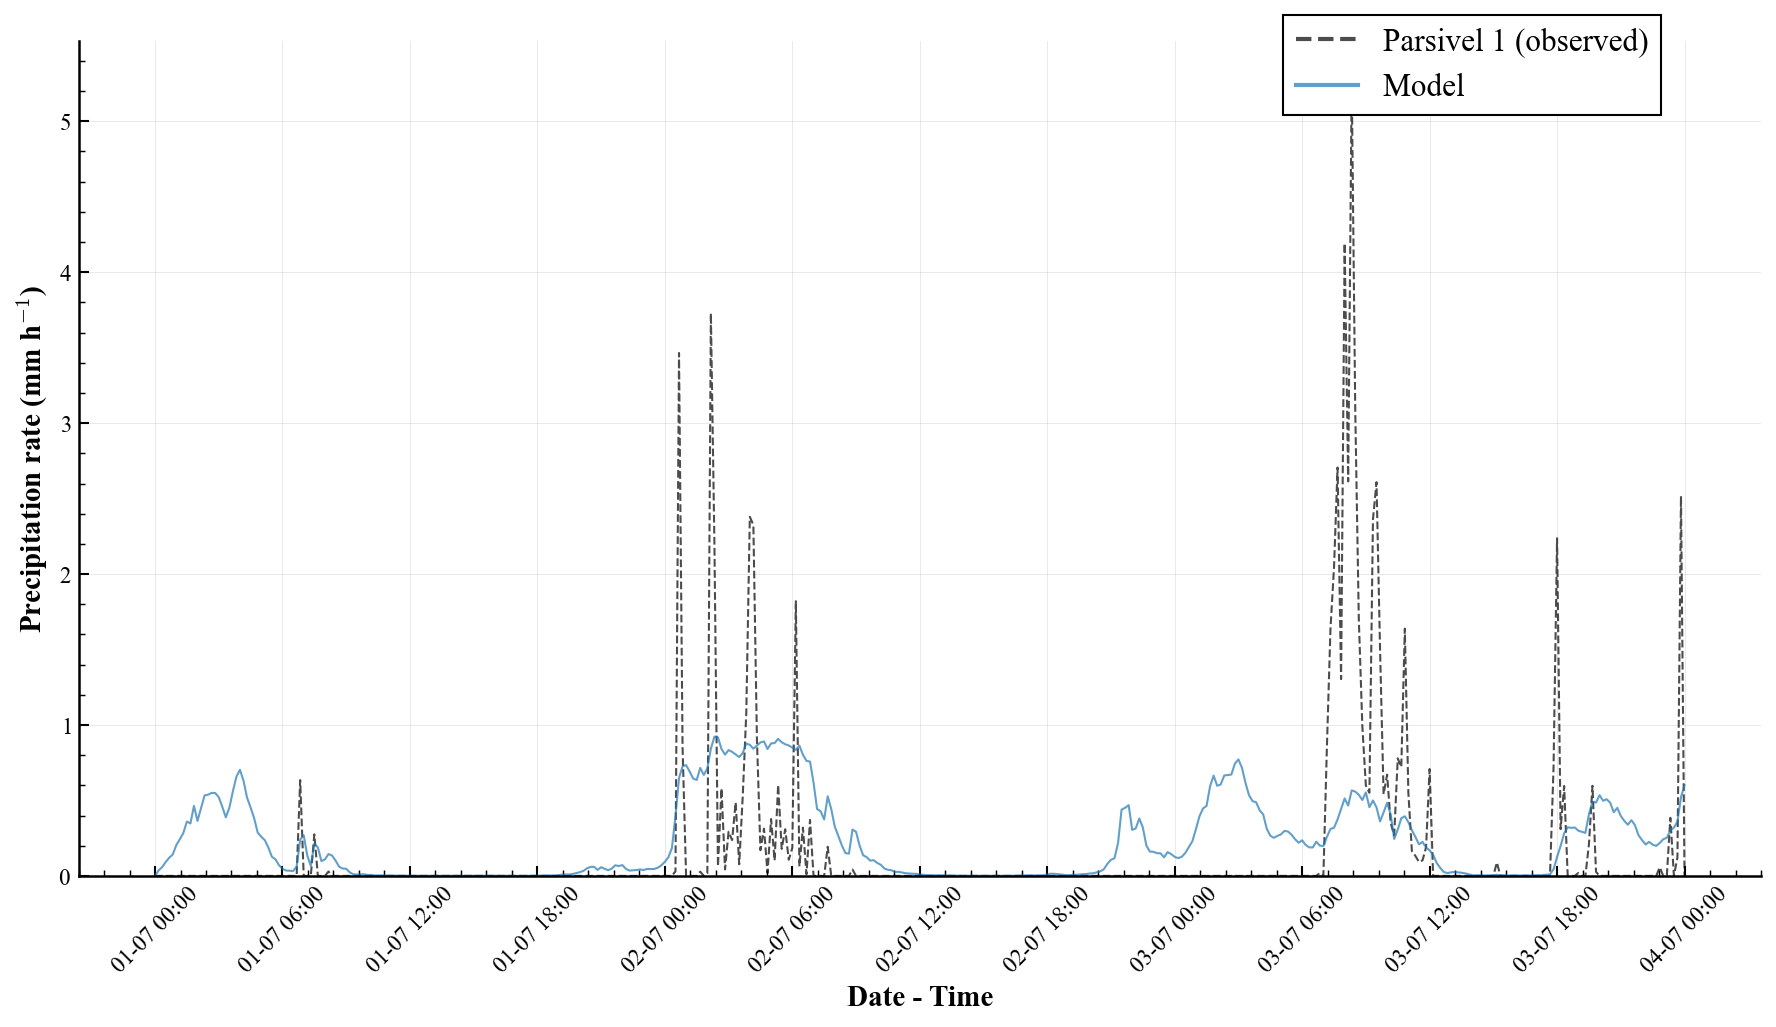

In [27]:
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
    
    # Axes and lines
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 20,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'xtick.minor.width': 0.7,
    'ytick.major.width': 1.0,
    'ytick.minor.width': 0.7,
    
    # Legend
    'legend.fontsize': 15,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'savefig.format': 'pdf',
})

import matplotlib.dates as mdates
from matplotlib.ticker import ScalarFormatter, MultipleLocator
import numpy as np

# Create figure
plt.figure(figsize=(12, 7))

# Scientific color palette (colorblind-friendly) - matching your style
colors = {
    'observed': '#000000',      # Black
    'model_1': '#1f77b4',      # Blue
    'model_2': '#ff7f0e',      # Orange
    'threshold': "#675AA0"     # Red for threshold
}

# Plot precipitation data
plt.plot(rain_rate.time,rain_rate, 
         label='Parsivel 1 (observed)', 
         color=colors['observed'], 
         alpha=0.7,
         linestyle='--',
         linewidth=1.0)

plt.plot(time, P[0] * 3600, 
         label='Model ', 
         color=colors['model_1'], 
         alpha=0.7,
         linewidth=1.0)

# Add precipitation threshold line for reference
threshold = 0.25  # mm/h
#plt.axhline(y=threshold, color=colors['threshold'], 
           #linestyle=':', alpha=0.7, linewidth=1.5,
           #label=f'Threshold ({threshold} mm h$^{{-1}}$)')

# Enhanced axis formatting - matching your style
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Proper time axis formatting (matching your existing code)
if hasattr(time, 'dtype') and 'datetime' in str(time.dtype):
    # For datetime data - every 6 hours with d-m format, starting from 00:00
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m %H:%M'))
    # Set locator to start from midnight (00:00) and show every 6 hours
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
    plt.setp(plt.gca().xaxis.get_majorticklabels(), rotation=45)
    plt.xlabel('Date - Time', fontweight='bold')
else:
    # For numeric time data (minutes) - every 6 hours = 360 minutes, starting from 0
    plt.xlabel('Time (min)', fontweight='bold')
    # Set tick spacing to every 6 hours starting from 0
    plt.gca().xaxis.set_major_locator(MultipleLocator(360))  # Every 6 hours if in minutes
    # Ensure the first tick is at 0 (00:00)
    plt.xlim(left=0)

# Scientific axis labels with proper units - matching your style
plt.ylabel('Precipitation rate (mm h$^{-1}$)', fontweight='bold')
#plt.title('Precipitation Rate Comparison', 
          #fontweight='bold', pad=20)

# Set y-axis to start from 0
plt.ylim(bottom=0)

# Scientific grid (matching your style)
plt.grid(True, alpha=0.2, linewidth=0.4, color='gray', linestyle='-')
plt.gca().set_axisbelow(True)

# Minor ticks for precision (matching your style)
plt.gca().minorticks_on()

# Professional y-axis formatting (matching your style)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.gca().yaxis.get_offset_text().set_fontsize(11)

# Scientific legend positioning (matching your style)
legend = plt.legend(loc='upper right',
                   frameon=True,
                   framealpha=1.0,
                   edgecolor='black',
                   facecolor='white',
                   borderaxespad=0.5,
                   bbox_to_anchor=(0.95, 1.05),
                   ncol=1)

# Set legend line width to match plot lines (matching your style)
for line in legend.get_lines():
    line.set_linewidth(2.0)

# Ensure proper aspect ratio and spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset rcParams
plt.rcParams.update(plt.rcParamsDefault)
